In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname, len(filenames))

/kaggle/input 0
/kaggle/input/datasets 0
/kaggle/input/datasets/salader 0
/kaggle/input/datasets/salader/dogsvscats 0
/kaggle/input/datasets/salader/dogsvscats/test 0
/kaggle/input/datasets/salader/dogsvscats/test/dogs 2500
/kaggle/input/datasets/salader/dogsvscats/test/cats 2500
/kaggle/input/datasets/salader/dogsvscats/train 0
/kaggle/input/datasets/salader/dogsvscats/train/dogs 10000
/kaggle/input/datasets/salader/dogsvscats/train/cats 10000
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs 0
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test 0
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/dogs 2500
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/cats 2500
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train 0
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/dogs 10000
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/cats 10000


In [3]:
import tensorflow as tf

train_path = "/kaggle/input/datasets/salader/dogsvscats/train"
test_path = "/kaggle/input/datasets/salader/dogsvscats/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(256, 256),
    batch_size=32,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(256, 256),
    batch_size=32,
    label_mode="binary"
)

Found 20000 files belonging to 2 classes.


2026-09-26 11:50:30.188586: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 5000 files belonging to 2 classes.


In [4]:
print(train_ds.class_names)

['cats', 'dogs']


In [5]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32, 1)


In [11]:
# Normalization

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

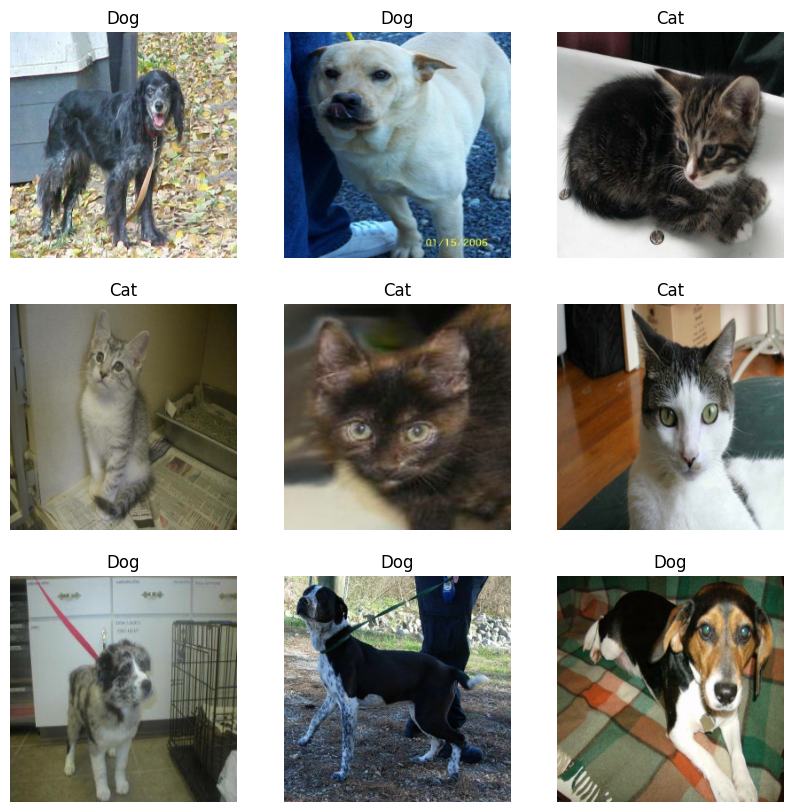

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title("Dog" if labels[i] == 1 else "Cat")
        plt.axis("off")

plt.show()

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
AveragePooling2D,Flatten
)

In [17]:
# Create an CNN Articture

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
260/625 ━━━━━━━━━━━━━━━━━━━━ 12:42 2s/step - accuracy: 0.5286 - loss: 0.7351

KeyboardInterrupt: 